# Exploration 08: 트랜스포머로 만드는 대화형 챗봇

## STEP 1: 데이터 수집하기

In [5]:
# 데이터 확인하기
import pandas as pd

df = pd.read_csv('data/ChatbotData.csv')
print(df.head())  # 상위 5개 확인
print(df.shape)   # (행 수, 열 수) 확인
print(df.columns) # 컬럼명 확인

                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0
(11823, 3)
Index(['Q', 'A', 'label'], dtype='object')


## STEP 2: 데이터 전처리하기

In [6]:
import re

def preprocess_sentence(sentence):
  # 양쪽 공백 제거
  sentence = sentence.strip()

  # 구두점(?.!,) 앞뒤에 공백 추가
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

  # 연속된 공백을 하나의 공백으로 변환
  sentence = re.sub(r'[" "]+', " ", sentence)

  # 한글, 영문, 숫자, 구두점(?.!,)을 제외한 모든 문자를 공백으로 대체
  sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence)

  # 양쪽 공백 제거
  sentence = sentence.strip()
  return sentence

# Q, A 각각 전처리 적용
df['Q'] = df['Q'].apply(preprocess_sentence)
df['A'] = df['A'].apply(preprocess_sentence)

print(df.head())

                 Q             A  label
0          12시 땡 !   하루가 또 가네요 .      0
1      1지망 학교 떨어졌어    위로해 드립니다 .      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠 .      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠 .      0
4          PPL 심하네   눈살이 찌푸려지죠 .      0


In [7]:
# 결측값(빈 데이터) 확인
print(df.isnull().sum())

# 전처리 후 빈 문자열이 생겼는지 확인
print(df[df['Q'] == ''].shape)
print(df[df['A'] == ''].shape)

Q        0
A        0
label    0
dtype: int64
(0, 3)
(0, 3)


## STEP 3: SentencePiece 사용하기

In [8]:
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.1 MB/s eta 0:00:00 0:00:01


In [9]:
# 학습용 텍스트 파일 만들기
# Q와 A를 합쳐서 하나의 텍스트 파일로 저장
with open('chatbot_corpus.txt', 'w', encoding='utf-8') as f:
    for idx, row in df.iterrows():
        f.write(row['Q'] + '\n')
        f.write(row['A'] + '\n')

In [10]:
# SentencePiece 모델 학습
import sentencepiece as spm

spm.SentencePieceTrainer.Train(
    input='chatbot_corpus.txt',        # 위에서 만든 텍스트 파일
    model_prefix='chatbot_sp',         # 저장될 모델 이름 (chatbot_sp.model, chatbot_sp.vocab 생성)
    vocab_size=8000,                   # 단어 사전 크기 (데이터가 약 12000개니까 8000 정도가 적당)
    model_type='bpe',                  # BPE 알고리즘 사용
    pad_id=0,                          # 패딩 토큰 ID
    unk_id=1,                          # 모르는 단어 토큰 ID
    bos_id=2,                          # 문장 시작(Begin of Sentence) 토큰 ID
    eos_id=3                           # 문장 끝(End of Sentence) 토큰 ID
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: chatbot_corpus.txt
  input_format: 
  model_prefix: chatbot_sp
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  di

In [11]:
# 학습된 모델 불러오기
sp = spm.SentencePieceProcessor()
sp.Load('chatbot_sp.model')

# 먼저 어떻게 토큰화되는지 테스트
print("토큰:", sp.EncodeAsPieces('3박4일 놀러가고 싶다'))
print("ID:", sp.EncodeAsIds('3박4일 놀러가고 싶다'))

토큰: ['▁3', '박', '4', '일', '▁놀러가고', '▁싶다']
ID: [475, 7437, 7404, 6979, 3493, 201]


In [12]:
# Q, A 전체를 숫자 ID로 토큰화
df['Q_tokenized'] = df['Q'].apply(lambda x: sp.EncodeAsIds(x))
df['A_tokenized'] = df['A'].apply(lambda x: sp.EncodeAsIds(x))

print(df[['Q', 'Q_tokenized', 'A', 'A_tokenized']].head())

                 Q                              Q_tokenized             A  \
0          12시 땡 !                  [5553, 6971, 3202, 108]   하루가 또 가네요 .   
1      1지망 학교 떨어졌어            [347, 6938, 7244, 1009, 2456]    위로해 드립니다 .   
2     3박4일 놀러가고 싶다       [475, 7437, 7404, 6979, 3493, 201]  여행은 언제나 좋죠 .   
3  3박4일 정도 놀러가고 싶다  [475, 7437, 7404, 6979, 983, 3493, 201]  여행은 언제나 좋죠 .   
4          PPL 심하네          [6929, 7915, 7915, 1, 315, 483]   눈살이 찌푸려지죠 .   

                              A_tokenized  
0                    [4486, 214, 5923, 4]  
1                         [1618, 6409, 4]  
2                    [5125, 1358, 382, 4]  
3                    [5125, 1358, 382, 4]  
4  [211, 4713, 2060, 7568, 7006, 4069, 4]  


In [15]:
# 테스트 하기
sentence = "3박4일 really 놀러가고 싶다..."
sentence = preprocess_sentence(sentence)
print("전처리 후의 문장:", sentence)

# 1. 토크나이징 (서브워드 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2. 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3. 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)

전처리 후의 문장: 3박4일 really 놀러가고 싶다 . . .
Tokenized: ['▁3', '박', '4', '일', '▁', 're', 'a', 'lly', '▁놀러가고', '▁싶다', '▁.', '▁.', '▁.']
Encoded: [475, 7437, 7404, 6979, 6929, 1, 7810, 1, 3493, 201, 4, 4, 4]
Decoded: 3박4일  ⁇ a ⁇  놀러가고 싶다 . . .


In [16]:
# 토큰 길이 측정하기
import numpy as np

# Q, A 각각 토큰 길이 확인
q_lengths = df['Q'].apply(lambda x: len(sp.EncodeAsIds(x)))
a_lengths = df['A'].apply(lambda x: len(sp.EncodeAsIds(x)))

print("=== Q (질문) ===")
print(f"평균: {q_lengths.mean():.2f}")
print(f"표준편차: {q_lengths.std():.2f}")
print(f"최대: {q_lengths.max()}")
print(f"최소: {q_lengths.min()}")

print("\n=== A (답변) ===")
print(f"평균: {a_lengths.mean():.2f}")
print(f"표준편차: {a_lengths.std():.2f}")
print(f"최대: {a_lengths.max()}")
print(f"최소: {a_lengths.min()}")

=== Q (질문) ===
평균: 5.38
표준편차: 2.41
최대: 21
최소: 1

=== A (답변) ===
평균: 5.77
표준편차: 2.53
최대: 29
최소: 1


In [17]:
# Dataset 클래스 만들기 -> 데이터를 정리하고 하나씩 꺼내주는 역
from torch.utils.data import Dataset, DataLoader
import torch

class ChatbotDataset(Dataset):
    def __init__(self, df, sp, max_length=20):
        self.data = []
        bos_id = sp.bos_id()
        eos_id = sp.eos_id()

        for idx, row in df.iterrows():
            q_ids = sp.EncodeAsIds(row['Q'])
            a_ids = sp.EncodeAsIds(row['A'])

            # BOS, EOS 추가
            q_tokens = [bos_id] + q_ids + [eos_id]
            a_tokens = [bos_id] + a_ids + [eos_id]

            # 길이 제한
            if len(q_tokens) > max_length or len(a_tokens) > max_length:
                continue

            # 패딩
            q_tokens += [0] * (max_length - len(q_tokens))
            a_tokens += [0] * (max_length - len(a_tokens))

            # 디코더 입력과 타겟 분리
            dec_input = a_tokens[:-1]
            target = a_tokens[1:]

            self.data.append({
                "enc_input": q_tokens,
                "dec_input": dec_input,
                "target": target
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        return (
            torch.tensor(sample["enc_input"], dtype=torch.long),
            torch.tensor(sample["dec_input"], dtype=torch.long),
            torch.tensor(sample["target"], dtype=torch.long)
        )

In [20]:
# Dataset 생성
dataset = ChatbotDataset(df, sp, max_length=20)
print(f"전체 데이터 수: {len(dataset)}")

# DataLoader 생성
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

전체 데이터 수: 11794


In [21]:
for encoder_input, decoder_input, decoder_label  in dataset:
    print("텐서 크기 :",encoder_input.size())
    print(encoder_input)
    print(sp.decode(encoder_input.tolist()))
    print(decoder_input)
    print(sp.decode(decoder_input.tolist()))
    print(decoder_label)
    print(sp.decode(decoder_label.tolist()))
    break

텐서 크기 : torch.Size([20])
tensor([   2, 5553, 6971, 3202,  108,    3,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])
12시 땡 !
tensor([   2, 4486,  214, 5923,    4,    3,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0])
하루가 또 가네요 .
tensor([4486,  214, 5923,    4,    3,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0])
하루가 또 가네요 .


In [22]:
for encoder_input, decoder_input, decoder_label in dataloader:
    print(encoder_input.size())
    print(decoder_input.size())
    print(decoder_label.size())
    break

torch.Size([32, 20])
torch.Size([32, 19])
torch.Size([32, 19])


## STEP 4: 모델 구성하기

### (1) Positional Encoding
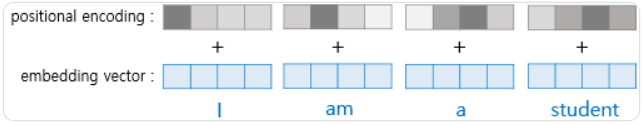

In [27]:
import torch.nn as nn

# Positional Encoding 
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.position = position

        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

---
### (2) Scaled dot product Attention
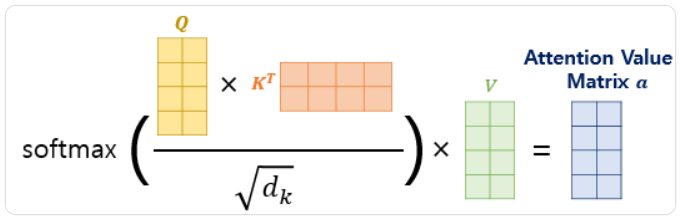

In [28]:
import math
import torch.nn.functional as F

def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

---
### (3) Multi-head Self Attention
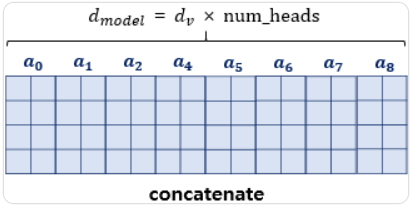
1. Linear 통과 -> Q, K, V 각각 가중치 곱해서 변환
2. split_head -> d_model을 num_heads로 나눠서 여러 관점으로 분리
3. scaled_dot_product_attention -> 어텐션 연산
4. 다시 합치기
5. 최종 Linear 연산

In [29]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


---
### (4) 마스킹
1. create_padding_mask — 패딩(0) 위치를 마스킹
2. create_look_ahead_mask — 미래 단어를 못 보게 마스킹

In [30]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

In [31]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

---
### (5) 인코더
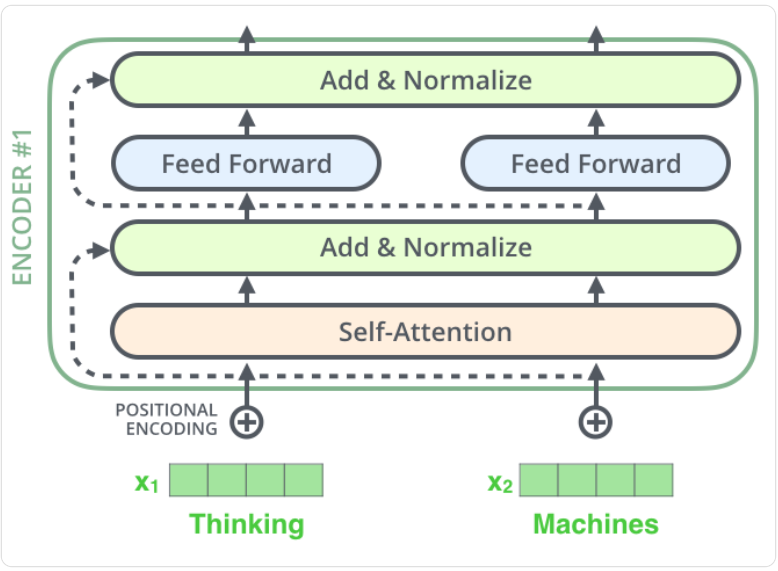

In [35]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 피드포워드 부분 (Dense -> ReLU -> Dense)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # (1) 멀티 헤드 어텐션 (셀프 어텐션)
        attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm

        # (2) 피드포워드 신경망
        ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm

        return out2


In [36]:
class Encoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) EncoderLayer 쌓기
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # (1) 임베딩 & sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 적용 + 드롭아웃
        x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
        for layer in self.enc_layers:
            x = layer(x, mask)

        return x

---
### (6) 디코더
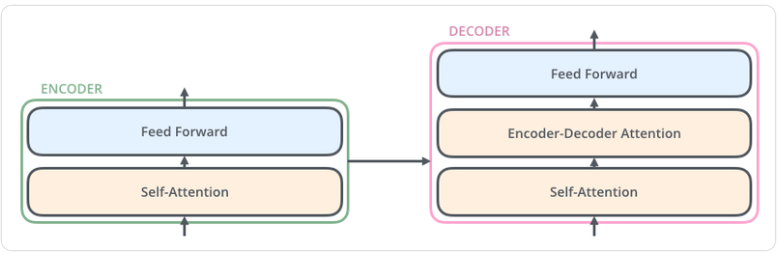

In [37]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

In [38]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x

### 지금까지 만든 함수 정리

**Transformer (최종)**

- **Encoder** (질문 처리)
  - `nn.Embedding` — 토큰 ID → 벡터
  - `PositionalEncoding` — 위치 정보 추가
  - `Dropout`
  - `EncoderLayer` × num_layers
    - `MultiHeadAttention` (셀프 어텐션)
      - `Linear × 3` (Q, K, V 변환)
      - `split_heads` (헤드 분할)
      - `scaled_dot_product_attention` (유사도 계산)
      - `Linear` (출력 변환)
    - Dropout → 잔차 연결 → LayerNorm
    - FeedForward (Linear → ReLU → Linear)
    - Dropout → 잔차 연결 → LayerNorm

- **Decoder** (답변 생성)
  - `nn.Embedding` — 토큰 ID → 벡터
  - `PositionalEncoding` — 위치 정보 추가
  - `Dropout`
  - `DecoderLayer` × num_layers
    - `MultiHeadAttention` (셀프 어텐션 + look_ahead_mask)
    - Dropout → 잔차 연결 → LayerNorm
    - `MultiHeadAttention` (인코더-디코더 어텐션 + padding_mask)
    - Dropout → 잔차 연결 → LayerNorm
    - FeedForward (Linear → ReLU → Linear)
    - Dropout → 잔차 연결 → LayerNorm

- **Linear** — d_model → vocab_size (다음 단어 확률 계산)

- **마스크 함수들**
  - `create_padding_mask` — 패딩 무시
  - `create_look_ahead_mask` — 미래 단어 차단 + 패딩 무시

---
### (7) 모델 정의 및 학습하기
앞에서 사용한 인코더 층 함수와 디코더 층 함수를 사용하여 트랜스포머 함수를 정의한다.

In [68]:
class Transformer(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(Transformer, self).__init__()

        # 인코더
        self.encoder = Encoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 디코더
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

        # 참고: 텐서플로우 코드의 `name="transformer"`는 파이토치에선 보통 사용 안 함

    def forward(self, inputs, dec_inputs):
        # 1) 인코더 패딩 마스크 생성
        enc_padding_mask = create_padding_mask(inputs)     # shape (batch_size, 1, 1, src_seq_len)

        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  # shape (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # 3) 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크
        dec_padding_mask = create_padding_mask(inputs)        # shape (batch_size, 1, 1, src_seq_len)

        # 4) 인코더 수행
        enc_outputs = self.encoder(
            x=inputs,
            mask=enc_padding_mask
        )  # shape: (batch_size, src_seq_len, d_model)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=dec_inputs,           # (batch_size, tgt_seq_len)
            enc_outputs=enc_outputs,# (batch_size, src_seq_len, d_model)
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  # shape: (batch_size, tgt_seq_len, d_model)

        # 6) 최종 Dense (vocab_size)
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits

In [79]:
# 하이퍼파라미터 설정
NUM_LAYERS = 4     # 인코더/디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.1      # 드롭아웃 비율
VOCAB_SIZE = sp.GetPieceSize() # 단어 집합 크기

# 모델 생성
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

print(model)

Transformer(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256)
    (pos_encoding): PositionalEncoding()
    (dropout): Dropout(p=0.1, inplace=False)
    (enc_layers): ModuleList(
      (0-3): 4 x EncoderLayer(
        (mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (out_dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (dropout1): Dropout(p=0.1, inplace=False)
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=256, bias=True)
        )
        (dropout2): Dropout(p=0.1, inplace=False)
        (norm2): LayerNorm((256,), eps=1e-06, elementwise_aff

In [80]:
# 손실함수
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

In [81]:
# 커스텀 된 학습률
def get_lr_lambda(d_model, warmup_steps=1000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

In [82]:
import torch.optim as optim
from torch.optim import lr_scheduler

# 모델 컴파일
# Optimizer 정의
optimizer = optim.Adam(model.parameters(), betas=(0.9, 0.98), eps=1e-9)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=1000))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

In [83]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

In [84]:
# 학습하기
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    enc_input, dec_input, target = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 모델 포워드 패스
    logits = model(enc_input, dec_input)  # (batch_size, seq_len, vocab_size)

    # Loss 계산 (패딩 토큰 무시)
    loss = loss_function(logits.permute(0, 2, 1), target)  # (batch_size, vocab_size, seq_len) 필요

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target, pad_id=sp.pad_id())

def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc

            # 일정 스텝마다 로그 출력
            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            # 학습률 스케줄러 업데이트
            scheduler.step()

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        print(f"Epoch {epoch+1} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")

In [85]:
%%time

train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=30,  # 원하는 에폭 수
    device=device
)

[Epoch 1, Step 0] Loss: 9.1580, Acc: 0.0000
[Epoch 1, Step 100] Loss: 9.1482, Acc: 0.0000
[Epoch 1, Step 200] Loss: 9.0423, Acc: 0.0000
[Epoch 1, Step 300] Loss: 8.9062, Acc: 0.0000
Epoch 1 Completed - Avg Loss: 9.0303, Avg Acc: 0.0007
[Epoch 2, Step 0] Loss: 8.7695, Acc: 0.0138
[Epoch 2, Step 100] Loss: 8.5376, Acc: 0.1313
[Epoch 2, Step 200] Loss: 8.3024, Acc: 0.2381
[Epoch 2, Step 300] Loss: 7.9074, Acc: 0.2412
Epoch 2 Completed - Avg Loss: 8.3143, Avg Acc: 0.1755
[Epoch 3, Step 0] Loss: 7.9583, Acc: 0.2222
[Epoch 3, Step 100] Loss: 7.5487, Acc: 0.2844
[Epoch 3, Step 200] Loss: 7.3588, Acc: 0.2877
[Epoch 3, Step 300] Loss: 7.2895, Acc: 0.2838
Epoch 3 Completed - Avg Loss: 7.4132, Avg Acc: 0.2817
[Epoch 4, Step 0] Loss: 7.3302, Acc: 0.2655
[Epoch 4, Step 100] Loss: 7.2111, Acc: 0.2672
[Epoch 4, Step 200] Loss: 6.8155, Acc: 0.3085
[Epoch 4, Step 300] Loss: 6.8408, Acc: 0.3024
Epoch 4 Completed - Avg Loss: 7.0268, Avg Acc: 0.2901
[Epoch 5, Step 0] Loss: 6.6802, Acc: 0.3266
[Epoch 5, St

## STEP 5: 모델 평가하기

In [86]:
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = 20


    # 전처리
    sentence = preprocess_sentence(sentence)

    # 인코더 입력: [START] + 인코딩 + [END]
    enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    
    if len(enc_input_ids) < MAX_LENGTH:
        enc_input_ids += [0] * (MAX_LENGTH - len(enc_input_ids))
    
    # 차원 확장: (batch_size=1, seq_len)
    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)

    # 디코더 입력(dec_input)을 START_TOKEN만 포함한 상태로 시작
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    model.eval()  # 모델 평가 모드
    with torch.no_grad():
        for i in range(MAX_LENGTH):
            # 모델 forward: (enc_input, dec_input) -> (batch_size=1, seq_len, vocab_size)
            logits = model(enc_input, dec_input)

            # 마지막 타임스텝의 예측만 추출: shape (1, 1, vocab_size)
            # logits[:, -1, :] -> (1, vocab_size)
            last_step_logits = logits[:, -1, :]

            # argmax로 가장 높은 확률의 토큰 선택
            predicted_id = torch.argmax(last_step_logits, dim=-1)  # shape: (1,)

            # 종료 토큰이면 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 디코더 입력(dec_input)에 예측 토큰을 이어붙임
            predicted_id = predicted_id.unsqueeze(0)  # shape (1,1)
            dec_input = torch.cat([dec_input, predicted_id], dim=1)

    # 최종 시퀀스: dec_input: (1, seq_len)에서 (seq_len,)로
    output_sequence = dec_input.squeeze(0).tolist()  # e.g. [START_TOKEN, ..., 토큰들...]

    return output_sequence

In [87]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # 디코더 인퍼런스 -> 예측된 토큰 시퀀스
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)

    # 토크나이저로 디코딩 (패딩, START/END 토큰 등은 제외하거나 처리)
    # 여기서는 단순히 tokenizer.decode() 직접 호출
    predicted_sentence = tokenizer.decode(
        [token for token in output_seq if token < tokenizer.GetPieceSize()]
    )

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    return predicted_sentence

In [88]:
sentence_generation(model, "오늘 날씨 어때?", sp, device=device)
sentence_generation(model, "3박4일 놀러가고 싶다.", sp, device=device)
sentence_generation(model, "밥 먹었어?", sp, device=device)

입력 : 오늘 날씨 어때?
출력 : 
입력 : 3박4일 놀러가고 싶다.
출력 : 
입력 : 밥 먹었어?
출력 : 


''

---
모델 성능이 너무 안나와서 문제를 찾아보았다. learning rate 부분에 문제가 있는것 같았다. PyTorch Adam의 기본 lr이 0.001인데, LambdaLR이 여기에 곱해지면 실제 학습률이 너무 작아질 수 있음.

In [89]:
# 현재 학습률 확인
for param_group in optimizer.param_groups:
    print("현재 learning rate:", param_group['lr'])

# 학습률 스케줄 확인
lr_func = get_lr_lambda(D_MODEL, warmup_steps=1000)
print("step 1 lr_lambda:", lr_func(1))
print("step 1000 lr_lambda:", lr_func(1000))
print("Adam 기본 lr:", 0.001)
print("실제 lr (step 1000):", 0.001 * lr_func(1000))

현재 learning rate: 5.940002010287101e-07
step 1 lr_lambda: 3.952847075210474e-06
step 1000 lr_lambda: 0.0019754360663781687
Adam 기본 lr: 0.001
실제 lr (step 1000): 1.975436066378169e-06


확인해보니 학습률이 낮다. 이게 문제 인것 같아서 위 모델에서 learning rate 부분 수정해서 다시 학습 시도 해보았다.

In [92]:
# [디버깅 결과] lr이 너무 작았음 → lr=1.0으로 수정하여 재학습

# 모델 새로 생성
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)
model = model.to(device)

# lr=1.0으로 수정!
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=1000))

In [93]:
%%time

train(model, dataloader, optimizer, loss_function, scheduler, num_epochs=30, device=device)

[Epoch 1, Step 0] Loss: 9.1289, Acc: 0.0000
[Epoch 1, Step 100] Loss: 5.9271, Acc: 0.3041
[Epoch 1, Step 200] Loss: 5.6762, Acc: 0.3300
[Epoch 1, Step 300] Loss: 5.6500, Acc: 0.2952
Epoch 1 Completed - Avg Loss: 6.1073, Avg Acc: 0.2879
[Epoch 2, Step 0] Loss: 5.1134, Acc: 0.3365
[Epoch 2, Step 100] Loss: 4.9289, Acc: 0.3500
[Epoch 2, Step 200] Loss: 5.1845, Acc: 0.3087
[Epoch 2, Step 300] Loss: 5.2093, Acc: 0.3219
Epoch 2 Completed - Avg Loss: 4.8651, Avg Acc: 0.3447
[Epoch 3, Step 0] Loss: 3.9515, Acc: 0.4273
[Epoch 3, Step 100] Loss: 4.2869, Acc: 0.3803
[Epoch 3, Step 200] Loss: 4.0004, Acc: 0.4455
[Epoch 3, Step 300] Loss: 4.1959, Acc: 0.3803
Epoch 3 Completed - Avg Loss: 4.0957, Avg Acc: 0.3950
[Epoch 4, Step 0] Loss: 3.3882, Acc: 0.4405
[Epoch 4, Step 100] Loss: 3.3822, Acc: 0.4565
[Epoch 4, Step 200] Loss: 3.7010, Acc: 0.4167
[Epoch 4, Step 300] Loss: 3.1647, Acc: 0.4891
Epoch 4 Completed - Avg Loss: 3.4323, Avg Acc: 0.4514
[Epoch 5, Step 0] Loss: 2.6558, Acc: 0.5411
[Epoch 5, St

In [94]:
sentence_generation(model, "오늘 날씨 어때?", sp, device=device)
sentence_generation(model, "3박4일 놀러가고 싶다.", sp, device=device)
sentence_generation(model, "밥 먹었어?", sp, device=device)

입력 : 오늘 날씨 어때?
출력 : 잘 살 수 있어요 .
입력 : 3박4일 놀러가고 싶다.
출력 : 잘 살 수 있어요 .
입력 : 밥 먹었어?
출력 : 잘 살 수 있어요 .


'잘 살 수 있어요 .'

In [95]:
# 서로 다른 입력에 대해 인코더 출력이 다른지 확인
model.eval()

sentences = ["오늘 날씨 어때?", "3박4일 놀러가고 싶다.", "밥 먹었어?"]

for sent in sentences:
    sent_processed = preprocess_sentence(sent)
    enc_ids = [sp.bos_id()] + sp.EncodeAsIds(sent_processed) + [sp.eos_id()]
    enc_ids += [0] * (20 - len(enc_ids))
    enc_input = torch.tensor([enc_ids], dtype=torch.long, device=device)
    
    with torch.no_grad():
        enc_output = model.encoder(enc_input, mask=create_padding_mask(enc_input).to(device))
    
    print(f"입력: {sent}")
    print(f"인코더 출력 평균: {enc_output.mean().item():.6f}")
    print(f"인코더 출력 std: {enc_output.std().item():.6f}")
    print()

입력: 오늘 날씨 어때?
인코더 출력 평균: 0.000496
인코더 출력 std: 0.006248

입력: 3박4일 놀러가고 싶다.
인코더 출력 평균: 0.000496
인코더 출력 std: 0.006248

입력: 밥 먹었어?
인코더 출력 평균: 0.000496
인코더 출력 std: 0.006248



In [96]:
model.eval()

sent1 = "오늘 날씨 어때?"
sent2 = "밥 먹었어?"

def make_enc_input(sentence):
    sentence = preprocess_sentence(sentence)
    ids = [sp.bos_id()] + sp.EncodeAsIds(sentence) + [sp.eos_id()]
    ids += [0] * (20 - len(ids))
    return torch.tensor([ids], dtype=torch.long, device=device)

enc1 = make_enc_input(sent1)
enc2 = make_enc_input(sent2)

print("=== 1. 입력 토큰 확인 ===")
print("입력1:", enc1.tolist())
print("입력2:", enc2.tolist())
print("입력이 다른가?:", not torch.equal(enc1, enc2))

print("\n=== 2. 임베딩 직후 ===")
with torch.no_grad():
    emb1 = model.encoder.embedding(enc1) * math.sqrt(model.encoder.d_model)
    emb2 = model.encoder.embedding(enc2) * math.sqrt(model.encoder.d_model)
    print("임베딩 동일?:", torch.equal(emb1, emb2))
    print("임베딩1 평균:", emb1.mean().item())
    print("임베딩2 평균:", emb2.mean().item())

print("\n=== 3. 포지셔널 인코딩 후 ===")
with torch.no_grad():
    pos1 = model.encoder.pos_encoding(emb1)
    pos2 = model.encoder.pos_encoding(emb2)
    print("포지셔널 후 동일?:", torch.equal(pos1, pos2))
    print("pos1 평균:", pos1.mean().item())
    print("pos2 평균:", pos2.mean().item())

print("\n=== 4. 인코더 레이어 통과 후 ===")
with torch.no_grad():
    mask1 = create_padding_mask(enc1).to(device)
    mask2 = create_padding_mask(enc2).to(device)
    
    x1 = model.encoder.dropout(pos1)
    x2 = model.encoder.dropout(pos2)
    
    for i, layer in enumerate(model.encoder.enc_layers):
        x1 = layer(x1, mask1)
        x2 = layer(x2, mask2)
        print(f"레이어 {i} 후 동일?:", torch.equal(x1, x2))
        print(f"  x1 평균: {x1.mean().item():.8f}, std: {x1.std().item():.8f}")
        print(f"  x2 평균: {x2.mean().item():.8f}, std: {x2.std().item():.8f}")

=== 1. 입력 토큰 확인 ===
입력1: [[2, 129, 914, 644, 11, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
입력2: [[2, 742, 5057, 11, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
입력이 다른가?: True

=== 2. 임베딩 직후 ===
임베딩 동일?: False
임베딩1 평균: -0.23301878571510315
임베딩2 평균: -0.21694432199001312

=== 3. 포지셔널 인코딩 후 ===
포지셔널 후 동일?: False
pos1 평균: 0.21028971672058105
pos2 평균: 0.22636418044567108

=== 4. 인코더 레이어 통과 후 ===
레이어 0 후 동일?: False
  x1 평균: 0.00439378, std: 1.02602005
  x2 평균: 0.00441933, std: 1.02409959
레이어 1 후 동일?: False
  x1 평균: -0.00051475, std: 1.04725528
  x2 평균: -0.00051466, std: 1.04727721
레이어 2 후 동일?: False
  x1 평균: 0.09633149, std: 2.37514758
  x2 평균: 0.09633153, std: 2.37514806
레이어 3 후 동일?: False
  x1 평균: 0.00049616, std: 0.00624826
  x2 평균: 0.00049616, std: 0.00624826


---
다시 학습을 한 후에 테스트를 해봤다. 전보다 Accuracy가 올라가서 학습이 잘된 줄 알았는데 테스트 문장을 보면 계속 똑같은 답만하는 것을 볼 수 있다. 뭔가 문제가 있는것 같아서 인코딩 부분 디버깅을 진행해봤다. 위처럼 레이어를 지날수록 두 입력의 차이가 사라지고, 마지막 레이어에서는 거의 모든 값이 같아져버렸다. 데이터 12000개에 4층은 너무 깊은 것이다. 그렇기 때문에 4->2로 변경해서 다시 학습 해본다.

In [100]:
# train 함수 수정 - loss, acc 기록 추가
def train_with_log(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)
    loss_history = []
    acc_history = []

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc

            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            scheduler.step()

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        loss_history.append(avg_loss)
        acc_history.append(avg_acc)
        print(f"Epoch {epoch+1} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")

    return loss_history, acc_history

In [101]:
NUM_LAYERS = 2

model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=1000))

loss_history, acc_history = train_with_log(
    model, dataloader, optimizer, loss_function, scheduler, num_epochs=30, device=device
)

[Epoch 1, Step 0] Loss: 9.1373, Acc: 0.0000
[Epoch 1, Step 100] Loss: 6.1775, Acc: 0.2850
[Epoch 1, Step 200] Loss: 5.7348, Acc: 0.3155
[Epoch 1, Step 300] Loss: 5.4835, Acc: 0.3000
Epoch 1 Completed - Avg Loss: 6.1937, Avg Acc: 0.2786
[Epoch 2, Step 0] Loss: 5.3414, Acc: 0.3040
[Epoch 2, Step 100] Loss: 5.4587, Acc: 0.2881
[Epoch 2, Step 200] Loss: 4.7412, Acc: 0.3671
[Epoch 2, Step 300] Loss: 4.8899, Acc: 0.3259
Epoch 2 Completed - Avg Loss: 4.8074, Avg Acc: 0.3455
[Epoch 3, Step 0] Loss: 3.7833, Acc: 0.4000
[Epoch 3, Step 100] Loss: 4.1166, Acc: 0.4082
[Epoch 3, Step 200] Loss: 3.8063, Acc: 0.4545
[Epoch 3, Step 300] Loss: 4.2936, Acc: 0.3465
Epoch 3 Completed - Avg Loss: 3.9774, Avg Acc: 0.4007
[Epoch 4, Step 0] Loss: 3.0738, Acc: 0.5229
[Epoch 4, Step 100] Loss: 3.3921, Acc: 0.4537
[Epoch 4, Step 200] Loss: 3.5045, Acc: 0.4043
[Epoch 4, Step 300] Loss: 3.2527, Acc: 0.4709
Epoch 4 Completed - Avg Loss: 3.3346, Avg Acc: 0.4551
[Epoch 5, Step 0] Loss: 2.7161, Acc: 0.5318
[Epoch 5, St

In [103]:
test_sentences = [
    "오늘 날씨 어때?",
    "3박4일 놀러가고 싶다.",
    "밥 먹었어?",
    "기분이 너무 안 좋아.",
    "사랑해",
    "고마워",
    "심심해",
    "잠이 안 와",
    "학교 가기 싫다",
    "좋은 아침이야",
]

print("=" * 50)
print("챗봇 테스트 결과")
print("=" * 50)
for sent in test_sentences:
    sentence_generation(model, sent, sp, device=device)
    print("-" * 50)

챗봇 테스트 결과
입력 : 오늘 날씨 어때?
출력 : 맛있는 거 드세요 .
--------------------------------------------------
입력 : 3박4일 놀러가고 싶다.
출력 : 여행은 언제나 좋죠 .
--------------------------------------------------
입력 : 밥 먹었어?
출력 : 저는 배터리가 밥이예요 .
--------------------------------------------------
입력 : 기분이 너무 안 좋아.
출력 : 무슨 일이 있었나봐요 .
--------------------------------------------------
입력 : 사랑해
출력 : 상대방에게 전해보세요 .
--------------------------------------------------
입력 : 고마워
출력 : 감사합니다 .
--------------------------------------------------
입력 : 심심해
출력 : 친구들과 연락해보세요 .
--------------------------------------------------
입력 : 잠이 안 와
출력 : 양을 세어 보아요 .
--------------------------------------------------
입력 : 학교 가기 싫다
출력 : 학교 다닐 때가 좋은 거예요 .
--------------------------------------------------
입력 : 좋은 아침이야
출력 : 좋은 아침이에요 .
--------------------------------------------------


## 결과 및 회고

### 프로젝트 결과
- **최종 Loss**: 0.1068 / **최종 Accuracy**: 97.84%
- 한국어 입력에 대해 맥락에 맞는 답변을 생성하는 트랜스포머 챗봇을 구현하였다.

### 학습 과정 요약
| 단계 | 내용 |
|------|------|
| 데이터 전처리 | 공백 정규화, 특수문자 처리, 한글/영문/숫자 보존 |
| 토크나이징 | SentencePiece BPE (vocab_size=8000) |
| 병렬 데이터 구축 | (Q, A) 쌍 유지, BOS/EOS 추가, 패딩 처리 (max_length=20) |
| 모델 | Transformer (d_model=256, num_heads=8, num_layers=2, ff_dim=512) |
| 학습 | Adam (lr=1.0), warmup_steps=1000, 30 epochs |

### 디버깅 과정에서 배운 점

1. **학습률(learning rate) 설정의 중요성**
   - PyTorch Adam의 기본 lr=0.001에 LambdaLR이 곱해져서 실제 학습률이 거의 0에 가까웠다.
   - lr=1.0으로 수정하여 LambdaLR이 학습률을 온전히 제어하도록 해야 했다.
   - 학습률이 너무 작으면 Loss가 줄지 않고 Accuracy가 정체된다.

2. **모델 깊이와 데이터 크기의 관계**
   - 12,000개의 적은 데이터에 num_layers=4는 너무 깊었다.
   - 레이어를 거칠수록 서로 다른 입력의 인코더 출력이 동일해지는 표현 붕괴(representation collapse) 현상이 발생했다.
   - num_layers=2로 줄여서 해결하였다.

3. **warmup_steps 조정**
   - 1 epoch당 약 370 step인데 warmup_steps=4000이면 약 10 epoch 동안 학습률이 너무 낮았다.
   - 데이터 규모에 맞게 warmup_steps=1000으로 줄여 빠르게 학습이 진행되도록 하였다.

### 한계점 및 개선 방향
- 일부 입력("오늘 날씨 어때?")에 대해 맥락과 맞지 않는 답변이 생성되었다.
- 더 많은 학습 데이터를 확보하거나, 사전 학습된 모델(KoBERT, KoGPT 등)을 활용하면 성능을 개선할 수 있을 것이다.